<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter13_Deploying_scikit_learn_Models_in_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 13 - Deploying scikit-learn Models in Production

Notebook ini membahas proses **deployment model machine learning** menggunakan scikit-learn.  
Fokus chapter ini adalah bagaimana sebuah model yang sudah dilatih tidak berhenti hanya di notebook eksperimen, tetapi bisa disimpan, dimuat kembali, diuji, dan dipakai untuk prediksi pada data baru.

Topik utama yang dibahas:
- overview deployment model
- serialisasi model dengan `joblib`
- menyimpan pipeline preprocessing + model
- memuat model untuk inferensi
- validasi input sebelum prediksi
- monitoring performa model
- simulasi workflow deployment sederhana

Pada chapter ini, kita menggunakan dataset **Breast Cancer Wisconsin** dari scikit-learn.

## 1. Tujuan Pembelajaran

Setelah menyelesaikan chapter ini, kita diharapkan mampu:

1. Memahami konsep dasar deployment model machine learning.
2. Menyimpan model scikit-learn ke file agar dapat digunakan kembali.
3. Memuat model yang telah disimpan tanpa perlu retraining.
4. Menggabungkan preprocessing dan model ke dalam pipeline yang siap deploy.
5. Melakukan prediksi pada data baru menggunakan model hasil deployment.
6. Membuat evaluasi sederhana untuk monitoring performa model.
7. Memahami alur dasar model lifecycle pada project machine learning.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

sns.set_style("whitegrid")
print("Library berhasil di-load.")

Library berhasil di-load.


## 2. Memuat Dataset

Untuk demonstrasi deployment, kita memakai **Breast Cancer Wisconsin dataset**.  
Dataset ini berisi fitur numerik hasil pengukuran sel tumor dan target klasifikasi:

- **0 = malignant**
- **1 = benign**

Dataset ini cocok untuk simulasi deployment karena:
- ukurannya tidak terlalu besar,
- fitur sudah numerik,
- mudah digunakan untuk membangun pipeline klasifikasi.

In [2]:
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

print("Ukuran dataset:", X.shape)
print("Nama target   :", cancer.target_names)

display(X.head())
print("\nDistribusi target:")
print(y.value_counts())

Ukuran dataset: (569, 30)
Nama target   : ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Distribusi target:
target
1    357
0    212
Name: count, dtype: int64


In [3]:
df = X.copy()
df["target"] = y

print("Informasi dataset:")
display(df.info())

print("\nStatistik ringkas:")
display(df.describe().T.head(10))

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothn

None


Statistik ringkas:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## 3. Train-Test Split

Sebelum deployment, model harus dilatih dan diuji terlebih dahulu.  
Karena tujuan chapter ini adalah simulasi production workflow, kita akan memisahkan data menjadi:

- **training set** → untuk melatih model
- **test set** → untuk mengevaluasi model sebelum disimpan

Pada praktik nyata, model yang akan dideploy sebaiknya sudah melalui proses validasi dan tuning yang memadai.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)

Ukuran X_train: (455, 30)
Ukuran X_test : (114, 30)


## 4. Membangun Pipeline Model

Dalam deployment, sangat disarankan menggunakan **Pipeline** agar preprocessing dan model menjadi satu objek.  
Keuntungannya:
1. mengurangi risiko lupa preprocessing saat inferensi,
2. lebih mudah disimpan,
3. lebih aman dipakai ulang pada data baru,
4. meminimalkan inkonsistensi antara training dan deployment.

Pada contoh ini kita gunakan:
- `StandardScaler`
- `LogisticRegression`

In [5]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

pipe.fit(X_train, y_train)

print("Pipeline berhasil dilatih.")
print(pipe)

Pipeline berhasil dilatih.
Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=5000))])


## 5. Evaluasi Model Sebelum Deployment

Sebelum model disimpan dan digunakan di production, kita perlu memastikan performanya cukup baik.  
Evaluasi dasar yang akan digunakan:
- accuracy
- ROC AUC
- confusion matrix
- classification report

In [6]:
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Evaluasi model sebelum deployment")
print("Accuracy :", round(acc, 4))
print("ROC AUC  :", round(auc, 4))

Evaluasi model sebelum deployment
Accuracy : 0.9825
ROC AUC  : 0.9954


In [7]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



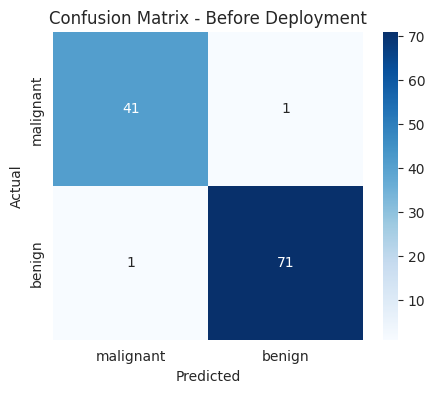

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Before Deployment")
plt.show()

## 6. Konsep Dasar Deployment Model

Secara sederhana, deployment model berarti memindahkan model dari lingkungan eksperimen ke lingkungan penggunaan nyata.  
Setelah model selesai dilatih, model tersebut bisa:

- disimpan ke file,
- dimuat kembali kapan saja,
- digunakan untuk prediksi data baru,
- dipanggil oleh aplikasi web, dashboard, API, atau sistem internal.

Alur sederhananya:
1. training model
2. evaluasi model
3. simpan model
4. muat model di lingkungan lain
5. lakukan prediksi pada data baru
6. monitor performa model seiring waktu

## 7. Menyimpan Model dengan Joblib

Salah satu cara paling umum untuk menyimpan model scikit-learn adalah dengan **joblib**.  
Kita akan menyimpan seluruh pipeline agar scaler dan model tersimpan bersama.

File model biasanya berekstensi:
- `.joblib`
- `.pkl`

Pada notebook ini kita gunakan folder lokal Colab terlebih dahulu.

In [9]:
model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "breast_cancer_pipeline.joblib")

joblib.dump(pipe, model_path)

print("Model berhasil disimpan di:")
print(model_path)

Model berhasil disimpan di:
saved_models/breast_cancer_pipeline.joblib


In [10]:
print("Daftar file pada folder model:")
print(os.listdir(model_dir))

Daftar file pada folder model:
['breast_cancer_pipeline.joblib']


## 8. Memuat Kembali Model

Keunggulan deployment adalah kita tidak perlu melatih ulang model setiap kali ingin melakukan prediksi.  
Cukup:
1. load file model,
2. siapkan data input,
3. panggil `predict()` atau `predict_proba()`.

Sekarang kita muat kembali model yang tadi disimpan.

In [11]:
loaded_model = joblib.load(model_path)

print("Model berhasil dimuat kembali.")
print(loaded_model)

Model berhasil dimuat kembali.
Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=5000))])


In [12]:
loaded_pred = loaded_model.predict(X_test)
loaded_proba = loaded_model.predict_proba(X_test)[:, 1]

print("Akurasi model hasil load:", round(accuracy_score(y_test, loaded_pred), 4))
print("ROC AUC model hasil load:", round(roc_auc_score(y_test, loaded_proba), 4))

Akurasi model hasil load: 0.9825
ROC AUC model hasil load: 0.9954


## 9. Membuktikan Bahwa Model Hasil Load Sama dengan Model Asli

Jika proses serialisasi berhasil, maka prediksi model hasil load seharusnya sama dengan model sebelum disimpan.  
Kita cek apakah seluruh hasil prediksinya identik.

In [13]:
same_predictions = np.array_equal(y_pred, loaded_pred)
print("Apakah prediksi model asli dan model hasil load sama?", same_predictions)

Apakah prediksi model asli dan model hasil load sama? True


## 10. Prediksi pada Data Baru

Pada deployment nyata, model akan menerima data baru yang belum pernah dilihat sebelumnya.  
Data ini bisa berasal dari:
- form input pengguna,
- file CSV,
- database,
- API request,
- sensor atau sistem lain.

Kita akan mencoba prediksi pada satu sampel baru.

In [14]:
new_sample = X.iloc[[0]].copy()
display(new_sample)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189


In [15]:
new_pred = loaded_model.predict(new_sample)[0]
new_proba = loaded_model.predict_proba(new_sample)[0]

label_map = {0: "malignant", 1: "benign"}

print("Prediksi kelas :", new_pred, "-", label_map[new_pred])
print("Probabilitas   :", new_proba)

Prediksi kelas : 0 - malignant
Probabilitas   : [9.99999994e-01 6.11810684e-09]


## 11. Simulasi Input Baru Secara Manual

Pada production, data baru sering masuk dalam bentuk dictionary, JSON, atau form input.  
Karena itu, penting untuk bisa mengubah input mentah menjadi DataFrame dengan struktur kolom yang sama seperti saat training.

In [16]:
manual_input = {
    col: X.iloc[10][col] for col in X.columns
}

manual_df = pd.DataFrame([manual_input])
display(manual_df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,16.02,23.24,102.7,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,...,19.19,33.88,123.8,1150.0,0.1181,0.1551,0.1459,0.09975,0.2948,0.08452


In [17]:
manual_pred = loaded_model.predict(manual_df)[0]
manual_proba = loaded_model.predict_proba(manual_df)[0]

print("Prediksi input manual :", label_map[manual_pred])
print("Probabilitas          :", manual_proba)

Prediksi input manual : malignant
Probabilitas          : [0.95307842 0.04692158]


## 12. Pentingnya Validasi Input

Dalam deployment, salah satu sumber error paling umum adalah **input yang tidak sesuai**.  
Masalah yang sering terjadi:
- kolom kurang
- urutan kolom salah
- tipe data tidak sesuai
- ada nilai kosong yang tidak ditangani
- nama fitur berbeda dengan saat training

Karena itu, sebelum prediksi kita perlu melakukan validasi input.

In [18]:
expected_columns = list(X.columns)

def validate_input(input_df, expected_columns):
    missing_cols = [col for col in expected_columns if col not in input_df.columns]
    extra_cols = [col for col in input_df.columns if col not in expected_columns]

    if missing_cols:
        raise ValueError(f"Kolom hilang: {missing_cols}")
    if extra_cols:
        raise ValueError(f"Kolom tidak dikenal: {extra_cols}")

    return input_df[expected_columns]

In [19]:
validated_df = validate_input(manual_df, expected_columns)
print("Input valid. Bentuk data:")
display(validated_df.head())

Input valid. Bentuk data:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,16.02,23.24,102.7,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,...,19.19,33.88,123.8,1150.0,0.1181,0.1551,0.1459,0.09975,0.2948,0.08452


## 13. Membuat Fungsi Prediksi Sederhana

Agar alur deployment lebih rapi, kita buat fungsi sederhana untuk:
1. menerima input DataFrame,
2. memvalidasi kolom,
3. menjalankan prediksi,
4. mengembalikan hasil prediksi dan probabilitas.

Fungsi seperti ini bisa menjadi cikal bakal endpoint API di masa depan.

In [20]:
def predict_with_model(model, input_df, expected_columns):
    input_df = validate_input(input_df, expected_columns)
    pred = model.predict(input_df)
    proba = model.predict_proba(input_df)

    result = input_df.copy()
    result["predicted_class"] = pred
    result["predicted_label"] = result["predicted_class"].map(label_map)
    result["prob_malignant"] = proba[:, 0]
    result["prob_benign"] = proba[:, 1]
    return result

In [21]:
prediction_result = predict_with_model(loaded_model, manual_df, expected_columns)
display(prediction_result.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,predicted_class,predicted_label,prob_malignant,prob_benign
0,16.02,23.24,102.7,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,...,0.1181,0.1551,0.1459,0.09975,0.2948,0.08452,0,malignant,0.953078,0.046922


## 14. Simulasi Batch Prediction

Selain prediksi satu data, deployment juga sering dipakai untuk memproses banyak data sekaligus.  
Misalnya:
- file CSV baru masuk setiap hari,
- sistem ingin menilai banyak transaksi sekaligus,
- model dipakai untuk scoring pelanggan secara massal.

Sekarang kita coba prediksi beberapa sampel sekaligus.

In [22]:
batch_df = X_test.iloc[:5].copy()
display(batch_df)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
256,19.55,28.77,133.60,1207.0,0.09260,0.20630,0.17840,0.11440,0.1893,0.06232,...,25.05,36.27,178.60,1926.0,0.1281,0.53290,0.4251,0.19410,0.2818,0.10050
428,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,11.68,20.29,74.35,421.1,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083
501,13.82,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,16.01,32.94,106.00,788.0,0.1794,0.39660,0.3381,0.15210,0.3651,0.11830
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,18.13,25.45,117.20,1009.0,0.1338,0.16790,0.1663,0.09123,0.2394,0.06469
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.45,26.40,166.10,2027.0,0.1410,0.21130,0.4107,0.22160,0.2060,0.07115


In [23]:
batch_result = predict_with_model(loaded_model, batch_df, expected_columns)
display(batch_result)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,predicted_class,predicted_label,prob_malignant,prob_benign
256,19.55,28.77,133.60,1207.0,0.09260,0.20630,0.17840,0.11440,0.1893,0.06232,...,0.1281,0.53290,0.4251,0.19410,0.2818,0.10050,0,malignant,1.000000,5.888242e-08
428,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083,1,benign,0.000011,9.999887e-01
501,13.82,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,0.1794,0.39660,0.3381,0.15210,0.3651,0.11830,0,malignant,0.993589,6.410825e-03
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,0.1338,0.16790,0.1663,0.09123,0.2394,0.06469,1,benign,0.466491,5.335085e-01
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,0.1410,0.21130,0.4107,0.22160,0.2060,0.07115,0,malignant,1.000000,6.525001e-10


## 15. Menyimpan Hasil Prediksi

Dalam sistem production, hasil prediksi biasanya tidak hanya ditampilkan, tetapi juga disimpan ke file, database, atau sistem lain.  
Sebagai simulasi sederhana, kita simpan hasil prediksi ke CSV.

In [24]:
prediction_output_path = os.path.join(model_dir, "sample_predictions.csv")
batch_result.to_csv(prediction_output_path, index=False)

print("Hasil prediksi disimpan ke:")
print(prediction_output_path)

Hasil prediksi disimpan ke:
saved_models/sample_predictions.csv


In [25]:
saved_predictions = pd.read_csv(prediction_output_path)
display(saved_predictions.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,predicted_class,predicted_label,prob_malignant,prob_benign
0,19.55,28.77,133.60,1207.0,0.09260,0.20630,0.17840,0.11440,0.1893,0.06232,...,0.1281,0.53290,0.4251,0.19410,0.2818,0.10050,0,malignant,1.000000,5.888242e-08
1,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083,1,benign,0.000011,9.999887e-01
2,13.82,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,0.1794,0.39660,0.3381,0.15210,0.3651,0.11830,0,malignant,0.993589,6.410825e-03
3,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,0.1338,0.16790,0.1663,0.09123,0.2394,0.06469,1,benign,0.466491,5.335085e-01
4,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,0.1410,0.21130,0.4107,0.22160,0.2060,0.07115,0,malignant,1.000000,6.525001e-10


## 16. Monitoring Performansi Model

Setelah model dideploy, pekerjaan belum selesai.  
Kita perlu memonitor performa model dari waktu ke waktu karena:

- distribusi data bisa berubah,
- pola data bisa bergeser,
- performa model bisa menurun,
- input baru bisa berbeda dari data training.

Monitoring sederhana bisa dilakukan dengan membandingkan metrik evaluasi pada batch data baru.

In [26]:
monitor_pred = loaded_model.predict(X_test)
monitor_proba = loaded_model.predict_proba(X_test)[:, 1]

monitor_acc = accuracy_score(y_test, monitor_pred)
monitor_auc = roc_auc_score(y_test, monitor_proba)

monitor_df = pd.DataFrame({
    "Metric": ["Accuracy", "ROC AUC"],
    "Value": [monitor_acc, monitor_auc]
})

display(monitor_df)

,Metric,Value
0,Accuracy,0.982456
1,ROC AUC,0.995370


## 17. Simulasi Penurunan Kinerja Model

Pada dunia nyata, performa model bisa turun ketika data baru berbeda dari data lama.  
Sebagai simulasi sederhana, kita bisa menganggap bahwa data baru memiliki distribusi yang sedikit bergeser.  
Di sini kita hanya membuat ilustrasi konseptual dengan memodifikasi sebagian fitur.

In [27]:
X_shifted = X_test.copy()

# simulasi drift sederhana: menggeser beberapa fitur
cols_to_shift = X_shifted.columns[:5]
for col in cols_to_shift:
    X_shifted[col] = X_shifted[col] * 1.05

shift_pred = loaded_model.predict(X_shifted)
shift_proba = loaded_model.predict_proba(X_shifted)[:, 1]

shift_acc = accuracy_score(y_test, shift_pred)
shift_auc = roc_auc_score(y_test, shift_proba)

drift_compare = pd.DataFrame({
    "Scenario": ["Original test data", "Shifted test data"],
    "Accuracy": [monitor_acc, shift_acc],
    "ROC AUC": [monitor_auc, shift_auc]
})

display(drift_compare)

,Scenario,Accuracy,ROC AUC
0,Original test data,0.982456,0.99537
1,Shifted test data,0.956140,0.99537


<Figure size 700x400 with 0 Axes>

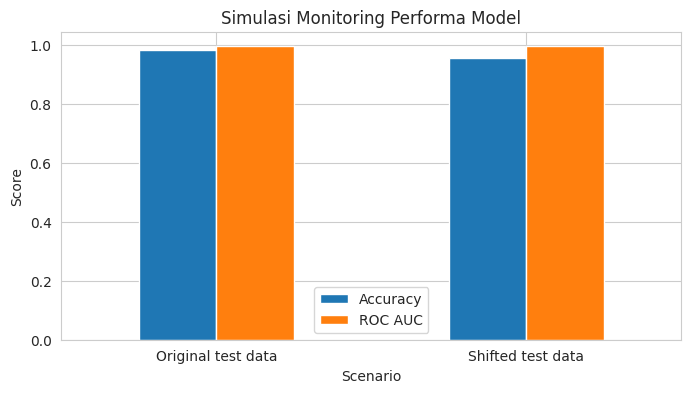

In [28]:
plt.figure(figsize=(7, 4))
drift_plot = drift_compare.set_index("Scenario")
drift_plot[["Accuracy", "ROC AUC"]].plot(kind="bar", figsize=(8, 4))
plt.title("Simulasi Monitoring Performa Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## 18. Model Lifecycle dalam Production

Secara umum, siklus hidup model machine learning di production mencakup:

1. **Data collection**  
   Mengumpulkan data baru dari sistem nyata.

2. **Training / retraining**  
   Melatih atau memperbarui model jika performa menurun.

3. **Validation**  
   Mengecek apakah model baru benar-benar lebih baik.

4. **Deployment**  
   Menyimpan dan mengaktifkan model baru untuk digunakan.

5. **Monitoring**  
   Mengamati performa model setelah dideploy.

6. **Maintenance**  
   Memperbaiki pipeline, fitur, atau parameter jika diperlukan.

## 19. Simulasi Versi Model

Dalam project nyata, model biasanya disimpan dengan versi berbeda agar mudah dilacak.  
Contoh:
- `model_v1.joblib`
- `model_v2.joblib`
- `model_v3.joblib`

Ini penting agar kita bisa:
- rollback ke model lama jika model baru bermasalah,
- membandingkan performa antar versi,
- menjaga reproducibility.

In [29]:
versioned_model_path = os.path.join(model_dir, "breast_cancer_pipeline_v1.joblib")
joblib.dump(pipe, versioned_model_path)

print("Model versi 1 disimpan di:")
print(versioned_model_path)

Model versi 1 disimpan di:
saved_models/breast_cancer_pipeline_v1.joblib


## 20. Menyimpan Metadata Model

Selain file model, sering kali kita juga perlu menyimpan metadata seperti:
- nama model
- versi model
- tanggal training
- jumlah fitur
- metrik evaluasi
- nama target

Metadata ini berguna untuk dokumentasi dan audit model.

In [30]:
metadata = {
    "model_name": "Breast Cancer Logistic Regression Pipeline",
    "version": "v1",
    "n_features": X.shape[1],
    "feature_names": list(X.columns),
    "target_names": list(cancer.target_names),
    "accuracy_test": float(acc),
    "roc_auc_test": float(auc)
}

metadata_df = pd.DataFrame({
    "Key": metadata.keys(),
    "Value": [str(v) for v in metadata.values()]
})

display(metadata_df)

,Key,Value
0,model_name,Breast Cancer Logistic Regression Pipeline
1,version,v1
2,n_features,30
3,feature_names,"['mean radius', 'mean texture', 'mean perimete..."
4,target_names,"[np.str_('malignant'), np.str_('benign')]"
5,accuracy_test,0.9824561403508771
6,roc_auc_test,0.9953703703703703


In [31]:
metadata_path = os.path.join(model_dir, "breast_cancer_pipeline_metadata.csv")
metadata_df.to_csv(metadata_path, index=False)

print("Metadata model disimpan di:")
print(metadata_path)

Metadata model disimpan di:
saved_models/breast_cancer_pipeline_metadata.csv


## 21. Praktik Baik Saat Deployment Model

Beberapa praktik baik yang perlu diperhatikan:

1. Gunakan **pipeline** agar preprocessing konsisten.
2. Simpan **versi model** dengan jelas.
3. Simpan **metadata** dan metrik evaluasi.
4. Validasi format input sebelum prediksi.
5. Monitor performa model setelah deployment.
6. Siapkan mekanisme retraining jika performa menurun.
7. Dokumentasikan alur prediksi dan struktur fitur.

## 22. Practical Exercise 1 — Saving and Reloading a Model Pipeline

Latihan pertama pada chapter ini adalah memastikan pipeline dapat:
- dilatih,
- disimpan,
- dimuat kembali,
- dan memberikan hasil prediksi yang konsisten.

In [32]:
exercise_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

exercise_model.fit(X_train, y_train)

exercise_path = os.path.join(model_dir, "exercise_pipeline.joblib")
joblib.dump(exercise_model, exercise_path)

exercise_loaded = joblib.load(exercise_path)

exercise_pred = exercise_loaded.predict(X_test)
exercise_acc = accuracy_score(y_test, exercise_pred)

print("Exercise 1 - Accuracy setelah reload:", round(exercise_acc, 4))

Exercise 1 - Accuracy setelah reload: 0.9825


## 23. Practical Exercise 2 — Monitoring Model Accuracy Over Time

Pada latihan kedua, kita membuat simulasi sederhana untuk memonitor accuracy model pada beberapa batch data.  
Tujuannya adalah melihat bahwa performa model bisa berubah pada batch data yang berbeda.

In [33]:
batch_metrics = []

batch_size = 20
num_batches = 5

for i in range(num_batches):
    start = i * batch_size
    end = start + batch_size

    X_batch = X_test.iloc[start:end]
    y_batch = y_test.iloc[start:end]

    pred_batch = loaded_model.predict(X_batch)
    acc_batch = accuracy_score(y_batch, pred_batch)

    batch_metrics.append({
        "Batch": i + 1,
        "Accuracy": acc_batch
    })

batch_metrics_df = pd.DataFrame(batch_metrics)
display(batch_metrics_df)

,Batch,Accuracy
0,1,0.95
1,2,1.00
2,3,0.95
3,4,1.00
4,5,1.00


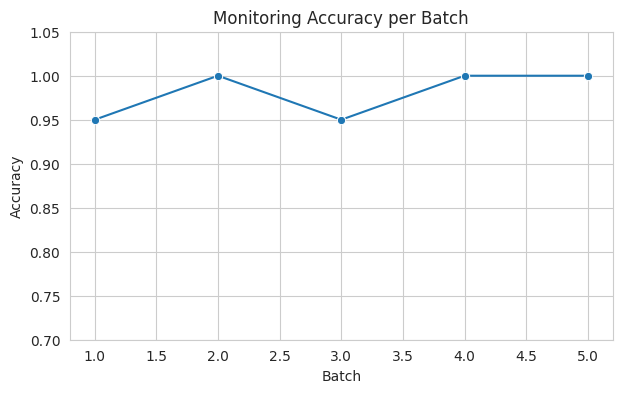

In [34]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=batch_metrics_df, x="Batch", y="Accuracy", marker="o")
plt.ylim(0.7, 1.05)
plt.title("Monitoring Accuracy per Batch")
plt.show()

## 24. Practical Exercise 3 — Deployment Validation Check

Pada deployment nyata, kita bisa menambahkan **validation threshold**.  
Misalnya:
- jika accuracy model di bawah threshold tertentu, model tidak boleh dipromosikan ke production.

Ini membantu menjaga kualitas model yang dideploy.

In [35]:
validation_threshold = 0.90
current_accuracy = acc

if current_accuracy >= validation_threshold:
    print(f"Model LOLOS deployment check. Accuracy = {current_accuracy:.4f}")
else:
    print(f"Model GAGAL deployment check. Accuracy = {current_accuracy:.4f}")

Model LOLOS deployment check. Accuracy = 0.9825


## 25. Ringkasan Konsep Chapter 13

Pada chapter ini kita mempelajari beberapa konsep penting deployment model:

- **serialization** → menyimpan model ke file
- **deserialization** → memuat model dari file
- **pipeline deployment** → menyimpan preprocessing dan model dalam satu objek
- **batch prediction** → prediksi untuk banyak data sekaligus
- **input validation** → memastikan format input sesuai
- **monitoring** → mengecek performa model dari waktu ke waktu
- **versioning** → menyimpan model dengan versi yang jelas
- **metadata management** → menyimpan informasi penting tentang model

In [36]:
summary_df = pd.DataFrame({
    "Konsep": [
        "Pipeline",
        "Joblib",
        "Model Reloading",
        "Input Validation",
        "Batch Prediction",
        "Monitoring",
        "Versioning",
        "Metadata"
    ],
    "Penjelasan": [
        "Menggabungkan preprocessing dan model menjadi satu alur",
        "Digunakan untuk menyimpan dan memuat model scikit-learn",
        "Menggunakan model yang telah disimpan tanpa retraining",
        "Memastikan data input sesuai format saat training",
        "Melakukan prediksi pada banyak data sekaligus",
        "Mengawasi performa model setelah deployment",
        "Menyimpan model dengan nama versi tertentu",
        "Menyimpan informasi tambahan seperti metrik dan fitur"
    ]
})

display(summary_df)

,Konsep,Penjelasan
0,Pipeline,Menggabungkan preprocessing dan model menjadi ...
1,Joblib,Digunakan untuk menyimpan dan memuat model sci...
2,Model Reloading,Menggunakan model yang telah disimpan tanpa re...
3,Input Validation,Memastikan data input sesuai format saat training
4,Batch Prediction,Melakukan prediksi pada banyak data sekaligus
5,Monitoring,Mengawasi performa model setelah deployment
6,Versioning,Menyimpan model dengan nama versi tertentu
7,Metadata,Menyimpan informasi tambahan seperti metrik da...


## 26. Kesimpulan Chapter 13

Chapter ini menunjukkan bahwa membangun model yang akurat hanyalah satu bagian dari machine learning project.  
Agar model benar-benar berguna, model tersebut harus bisa **disimpan, dimuat kembali, digunakan untuk data baru, dan dipantau performanya**.

Poin penting chapter ini:
1. Model sebaiknya disimpan dalam bentuk **pipeline** agar preprocessing konsisten.
2. **Joblib** memudahkan proses serialisasi dan deserialisasi model scikit-learn.
3. Deployment membutuhkan **validasi input** agar model tidak gagal saat menerima data baru.
4. **Monitoring** penting untuk mendeteksi penurunan performa akibat perubahan data.
5. **Versioning** dan **metadata** membantu pengelolaan model dalam jangka panjang.

Secara keseluruhan, deployment bukan hanya soal menyimpan model, tetapi juga tentang memastikan model dapat digunakan secara aman, konsisten, dan terukur di lingkungan production.

## 27. Ringkasan Singkat Chapter 13

Isi notebook ini meliputi:
- memuat dataset klasifikasi
- membuat pipeline Logistic Regression
- mengevaluasi model sebelum deployment
- menyimpan model dengan joblib
- memuat kembali model yang sudah disimpan
- melakukan prediksi pada data baru
- membuat fungsi prediksi sederhana
- melakukan batch prediction
- menyimpan hasil prediksi ke file
- membuat simulasi monitoring performa
- menyimpan versi model dan metadata

In [37]:
print("Notebook Chapter 13 selesai dijalankan.")
print("Topik utama: Deploying scikit-learn Models in Production")

Notebook Chapter 13 selesai dijalankan.
Topik utama: Deploying scikit-learn Models in Production
